<a href="https://colab.research.google.com/github/tsubasa-iino/psi4book/blob/main/compchem_book_ch10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 10章 反応機構を計算してみよう

### 環境構築

#### Google Colab上にPsi4をインストール

In [1]:
!pip install -q condacolab
import condacolab
import os

# バグ回避パッチ
if "LD_LIBRARY_PATH" not in os.environ:
    os.environ["LD_LIBRARY_PATH"] = ""

print("Installing CondaColab (Base)...")
condacolab.install()

Installing CondaColab (Base)...
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


ランタイム｜セッションを再起動する｜はい を実行。

In [ ]:
import condacolab
import os
import sys

condacolab.check()

# 1. 邪魔なPinningを削除
if os.path.exists("/usr/local/conda-meta/pinned"):
    !rm /usr/local/conda-meta/pinned

# 2. Python 3.12 と Psi4 をインストール（ディスク書き換え）
print("Upgrading Python to 3.12 & Installing Psi4...")
!mamba install -y -q python=3.12 psi4 -c conda-forge/label/libint_dev -c conda-forge

# 3. Pinningの復元（成功環境の再現）
os.makedirs("/usr/local/conda-meta", exist_ok=True)
with open("/usr/local/conda-meta/pinned", "w") as f:
    f.write("python 3.12.*\n")

# 4. 【最重要】カーネルの自殺（強制再起動）
# これにより、メモリ上のPython 3.11を殺し、ディスク上のPython 3.12をロードさせます
print("\n🔄 RESTARTING KERNEL TO LOAD PYTHON 3.12...")
import time
time.sleep(1)
os.kill(os.getpid(), 9)

✨🍰✨ Everything looks OK!
Upgrading Python to 3.12 & Installing Psi4...
Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done

🔄 RESTARTING KERNEL TO LOAD PYTHON 3.12...


ランタイム｜セッションを再起動する｜はい を実行。

In [1]:
import sys
import os

# パスが通っていなければ通す
target_path = "/usr/local/lib/python3.12/site-packages"
if target_path not in sys.path:
    sys.path.insert(0, target_path)

import psi4
print(f"✅ Restart Successful.")
print(f"Psi4 Version: {psi4.__version__}")
print(f"Python Version: {sys.version.split()[0]}") # ここが3.12になっているはず

# 計算テスト
psi4.set_memory('500 MB')
mol = psi4.geometry("O\nH 1 0.96\nH 1 0.96 2 104.5")
en = psi4.energy('scf/cc-pvdz')
print(f"Energy: {en:.6f}")

✅ Restart Successful.
Psi4 Version: 1.10
Python Version: 3.12.12
Energy: -76.026633


ここまででインストール確認完了。

In [2]:
import os
import datetime
import numpy as np
import pandas as pd
import psi4

print(f'current time: {datetime.datetime.now()}')
print(f'python version:\n{sys.version}')
print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'psi4 version: {psi4.__version__}')

current time: 2026-01-21 12:05:02.947146
python version:
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy version: 2.0.2
pandas version: 2.2.2
psi4 version: 1.10


#### 必要なライブラリと関数の定義

In [3]:
# 振動数可視化のためのライブラリ
!pip install py3Dmol
import py3Dmol

!git clone https://github.com/duerrsimon/normal-mode-jupyter.git
sys.path.append('/content/normal-mode-jupyter')
from helpers import show_normal_modes

Cloning into 'normal-mode-jupyter'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 23 (delta 8), reused 17 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 801.96 KiB | 5.24 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [4]:
def show_3D(mol: psi4.core.Molecule) -> py3Dmol.view:
    """
    Psi4のMoleculeオブジェクトをpy3Dmolで描画する
    Args:
        mol: 描画対象の分子

    Returns:
        py3Dmol.view: py3Dmolの描画オブジェクト

    """
    view = py3Dmol.view(width=400, height=400)
    xyz = mol.save_string_xyz_file()
    view.addModel(xyz, 'xyz')
    #view.setStyle({'stick': {}})  # これだと遷移状態でCl原子が表示されないので下記に変更
    view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
    view.setBackgroundColor('#e1e1e1')
    view.zoomTo()

    return view.show()

In [5]:
def optfreq(mol: psi4.core.Molecule,
            theory: str) -> list[float, psi4.core.Wavefunction]:
    """
    分子の構造最適化と振動数計算を行う

    Args:
        mol (psi4.core.Molecule): 計算対象の分子
        theory: 計算レベル

    Returns:
        float: エネルギー
        psi4.core.Wavefunction: 計算のWavefunction

    """
    _, wfn = psi4.optimize(theory,
                           molecule=mol,
                           return_wfn=True)
    energy, wfn = psi4.frequency(theory,
                                 molecule=mol,
                                 ref_gradient=wfn.gradient(),
                                 return_wfn=True)

    return [energy, wfn]


def get_freqs(wavefunction: psi4.core.Wavefunction) -> np.ndarray:
    """
    Wavefunctionオブジェクトから振動数を取り出す
    Args:
        wavefunction: 対象のWavefunctionオブジェクト

    Returns:
        振動数のarrray

    """
    return wavefunction.frequencies().to_array()


#### 計算資源の設定

In [6]:
# 計算資源の確認（CPU, RAM）
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 79
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2199.998
cache size	: 56320 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm rdseed adx smap xsaveopt arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmio_stale_data retbleed bhi its
bogomips	: 4399.99
clflush size	: 64
cache_alignment	: 64
address sizes

In [7]:
!cat /proc/meminfo

MemTotal:       13286964 kB
MemFree:          550468 kB
MemAvailable:   11793772 kB
Buffers:          191680 kB
Cached:         10875388 kB
SwapCached:            0 kB
Active:          1234680 kB
Inactive:       10810776 kB
Active(anon):       2676 kB
Inactive(anon):   979064 kB
Active(file):    1232004 kB
Inactive(file):  9831712 kB
Unevictable:           8 kB
Mlocked:               8 kB
SwapTotal:             0 kB
SwapFree:              0 kB
Dirty:              3416 kB
Writeback:             0 kB
AnonPages:        978412 kB
Mapped:           534472 kB
Shmem:              3344 kB
KReclaimable:     505232 kB
Slab:             578004 kB
SReclaimable:     505232 kB
SUnreclaim:        72772 kB
KernelStack:        5272 kB
PageTables:        18404 kB
SecPageTables:         0 kB
NFS_Unstable:          0 kB
Bounce:                0 kB
WritebackTmp:          0 kB
CommitLimit:     6643480 kB
Committed_AS:    3026408 kB
VmallocTotal:   34359738367 kB
VmallocUsed:       11736 kB
VmallocChunk:    

In [8]:
n_cpu = os.cpu_count()
ram = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024 ** 3)

In [9]:
# 環境に応じて計算資源を設定
psi4.set_num_threads(n_cpu)
psi4.set_memory(f'{ram * 0.9: .0f}GB')

11000000000

### 10.2　遷移状態を計算してみよう

#### 1,2-ジクロロエタン

In [10]:
psi4.set_output_file('dce_ts.log')

# 二面角0度の初期構造
dce = psi4.geometry('''
0 1
 C                 -2.52697099    1.46473027    0.00000000
 H                 -2.17029815    1.96912846   -0.87365150
 H                 -3.59697099    1.46474345    0.00000000
 C                 -2.01365528    0.01279812    0.00000000
 H                 -2.84588587   -0.65972864    0.00000086
 H                 -1.41921341   -0.15534323   -0.87365174
 Cl                -1.94029417    2.29439458    1.43703425
 Cl                -1.03587983   -0.26377103    1.43703329
 ''')

In [11]:
# 遷移状態計算に設定
psi4.set_options({'opt_type': 'TS',
                  'normal_modes_write': True})

In [12]:
# 構造最適化・振動数計算
_, wfn_dce = optfreq(dce, 'hf/sto-3g')

Optimizer: Optimization complete!


In [13]:
print(get_freqs(wfn_dce))

[-182.75261977  205.22177061  507.46279799  830.54958692  885.10379975
  990.54995148 1143.74821757 1237.99691205 1393.93272261 1476.13331362
 1550.11701470 1574.31353470 1766.57498055 1787.38189007 3616.29338284
 3620.23745750 3738.09841446 3745.70312713]


In [14]:
print(dce.save_string_xyz())

0 1
 C   -0.796789841095    0.546933472412   -0.985065329073
 H   -0.441734272721    1.057558908665   -1.880250174638
 H   -1.886779533317    0.546449337982   -0.994553941732
 C   -0.275709004284   -0.926104186220   -0.985230717638
 H   -1.123644679940   -1.610982209761   -0.995519795214
 H    0.322012496540   -1.099656302247   -1.880091853360
CL   -0.296101258093    1.567648879320    0.420735955489
CL    0.754355515759   -1.405637894857    0.421126538025



In [15]:
with open('dce_ts.xyz', 'w') as f:
    f.write(dce.save_string_xyz_file())

In [16]:
show_3D(dce)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [18]:
# 振動数を可視化（左サイドバーから.molden_normal_modesファイルの名前を参照し指定する。ファイル名の番号は実行時のOSプロセスID）
show_normal_modes('dce_ts.default.2287.molden_normal_modes')

interactive(children=(Dropdown(description='Normal mode:', options=((-182.7526197745, 0), (205.2217706094, 1),…

### 10.3 遷移状態計算のコツ

In [19]:
import matplotlib.pyplot as plt

#### 反応座標軸に沿った構造のスキャン：SN2反応

##### スキャン

In [20]:
psi4.core.clean_options()
psi4.set_output_file('sn2_scan.log')

PosixPath('sn2_scan.log')

In [21]:
# Z座標を変数として扱えるように構造を定義
sn2_geom = '''
 -1 1
 C                 -0.37149818    0.23751522    0.00000000
 H                  0.13279358   -0.63613612    0.35682369
 H                 -1.38041486    0.23751522    0.35635256
 H                  0.13279358    1.11116656    0.35682369
 Cl                -0.37090351    0.23751522   -1.90999991
 Cl                -0.37090351    0.23751522   {}
'''

In [22]:
energies = []
geometries = []
distance = np.arange(1.7, 2.8, 0.1)
psi4.set_options({'GEOM_MAXITER': 200,
                  'FROZEN_DISTANCE': '1 6',
                  'INTRAFRAG_STEP_LIMIT_MAX': 0.5,
                  'OPT_COORDINATES': 'CARTESIAN'})

# 距離を変えながら構造最適化
for dist in distance:
    ts = psi4.geometry(sn2_geom.format(dist))
    energy = psi4.optimize('b3lyp/6-31g(d)', molecule=ts)
    energies.append(energy)
    geometries.append(ts.save_string_xyz())

Hessian guess encountered unknown coordinate type.



Optimizer: Optimization complete!


Hessian guess encountered unknown coordinate type.



Optimizer: Optimization complete!


Hessian guess encountered unknown coordinate type.



...

Optimizer: Optimization complete!


Hessian guess encountered unknown coordinate type.



Optimizer: Optimization complete!


Hessian guess encountered unknown coordinate type.



Optimizer: Optimization complete!


In [23]:
len(energies)

11

In [24]:
energies

[-960.3723228854325,
 -960.3792913763398,
 -960.3802021089474,
 -960.3781268010803,
 -960.3750089467053,
 -960.372026389622,
 -960.3699864036464,
 -960.3697135340399,
 -960.3715405189354,
 -960.3742231298666,
 -960.3766564563616]

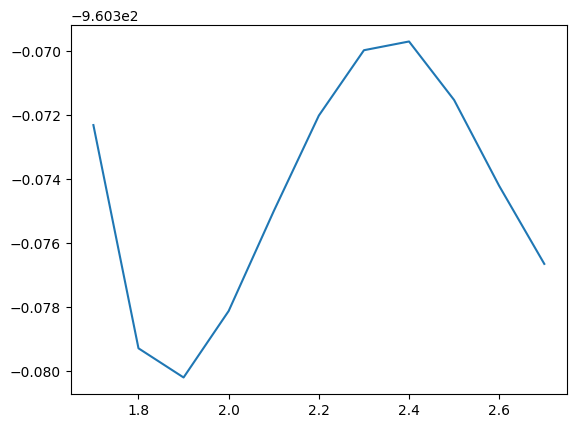

In [25]:
plt.plot(distance, energies)

In [26]:
# エネルギー最大値を与える距離を出力
idx = np.argmax(np.array(energies))
print(idx)
print(f'maximum energy at {distance[idx]: .1f} angstrom')

7
maximum energy at  2.4 angstrom


In [27]:
print(geometries[idx])

-1 1
 C    0.000188825256   -0.048782966183    0.000000000000
 H   -0.536239293355   -0.000923732450   -0.929161600963
 H    1.073129177135   -0.000880219557    0.000000000000
 H   -0.536239293355   -0.000923732450    0.929161600963
CL   -0.000077159484   -2.334397999760    0.000000000000
CL   -0.000006388707    2.351217099552    0.000000000000



##### 遷移状態の最適化

In [28]:
psi4.core.clean_options()
psi4.set_options({'OPT_TYPE': 'TS',
                  'GEOM_MAXITER': 100,
                  'OPT_COORDINATES': 'CARTESIAN',
                  'INTRAFRAG_STEP_LIMIT_MAX': 0.5,
                  'FULL_HESS_EVERY': 0,
                  'normal_modes_write': True})
psi4.set_output_file('SN2_OPT_TS.log')

PosixPath('SN2_OPT_TS.log')

In [29]:
ts = psi4.geometry(geometries[idx])
_, wfn_sn2 = optfreq(ts, 'b3lyp/6-31g(d)')

Optimizer: Optimization complete!


In [30]:
print(get_freqs(wfn_sn2))

[-328.52174386  195.09395541  200.29699048  211.16771154  924.23592758
  924.38480354 1026.42189870 1424.47657764 1424.67402001 3232.95889247
 3428.27917611 3428.34435545]


In [31]:
# 振動数を可視化（左サイドバーから.molden_normal_modesファイルの名前を参照し指定する。ファイル名の番号は実行時のOSプロセスID）
show_normal_modes('SN2_OPT_TS.CCl2H3.2287.molden_normal_modes')

interactive(children=(Dropdown(description='Normal mode:', options=((-328.5217438585, 0), (195.0939554111, 1),…

In [32]:
print(ts.save_string_xyz())

-1 1
 C    0.288084649059    0.073747652422    0.000000000000
 H   -0.247340083629    0.033201012589   -0.930068557363
 H    1.359048471589    0.154124747513    0.000000000000
 H   -0.247340083629    0.033201012589    0.930068557363
CL    0.465475433967   -2.283469727451    0.000000000000
CL    0.110387802261    2.429941778629    0.000000000000



#### 簡単な遷移状態から始める

In [33]:
ts_2 = psi4.geometry('''
-1 1
C        0.2649260080     -0.0067094977      0.0000000000
H       -0.2717752670     -0.0312506114     -0.9301314632
C        1.3381167522      0.0418605925      0.0000000000
C       -0.2717752670     -0.0312506114      0.9301314632
Cl       0.3727604714     -2.3688191841      0.0000000000
Cl       0.1571287303      2.3544767471      0.0000000000
H        1.6944025173      0.0582577786     -1.0088070112
H        1.7339248047     -0.8149079124      0.5041663560
H        1.6549282236      0.9306064646      0.5046397392
H       -1.3226464201     -0.0787576909      0.7343946575
H       -0.0531535919      0.8530376826      1.4915036894
H        0.0258452199     -0.8924765946      1.4910341746
''')

In [34]:
show_3D(ts_2)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

##### 制約付き最適化

In [35]:
psi4.core.clean_options()
psi4.set_options({
    'GEOM_MAXITER': 200,
    'FROZEN_CARTESIAN': '1 XYZ 5 XYZ 6 XYZ'
})
psi4.set_output_file('SN2_OPT2.log')

PosixPath('SN2_OPT2.log')

In [36]:
psi4.optimize('b3lyp/6-31g(d)', molecule=ts_2)

Optimizer: Optimization complete!


-1038.9799421729901

In [37]:
show_3D(ts_2)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

##### 遷移状態最適化

In [38]:
psi4.core.clean_options()
psi4.set_options({
    'OPT_TYPE': 'TS',
    'GEOM_MAXITER': 100,
    'OPT_COORDINATES': 'CARTESIAN',
    'INTRAFRAG_STEP_LIMIT_MAX': 0.5,
    'FULL_HESS_EVERY': 0,
    'NORMAL_MODES_WRITE': True,
})
psi4.set_output_file('SN2_OPT_TS2.log')

PosixPath('SN2_OPT_TS2.log')

In [39]:
_, wfn_sn2_2 = optfreq(ts_2, 'b3lyp/6-31g(d)')

 '428.1972']
Optimizer: Optimization complete!
 '334.9206' '392.2644']


In [40]:
print(get_freqs(wfn_sn2_2))

[-306.21573469  101.61799708  130.60775858  172.54964937  176.93617685
  185.18294499  275.17999628  334.92059027  392.26442305  899.25080926
  909.53475848  955.66338377  994.57925513 1084.37923994 1139.24103197
 1192.62032371 1366.43861884 1420.20827653 1444.11028353 1497.17426631
 1498.17518827 1514.43212138 1519.64652586 3062.89153789 3066.25256304
 3125.27283448 3129.73815196 3156.31214318 3157.73702903 3378.40685413]


In [41]:
show_3D(ts_2)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [42]:
ts_2.save_xyz_file('sn2_ts2.xyz', True)

In [43]:
print(ts_2.save_string_xyz())

-1 1
 C   -0.070387301531    0.000487393635   -0.147337203033
 H   -0.590342630742   -0.013261233846   -1.084328732494
 C    1.383335199019    0.378777340566   -0.086722295509
 C   -0.783576053130   -0.357802639920    1.126669523652
CL    0.311232910846   -2.372614255883   -0.898642768297
CL   -0.939007769192    2.361222991096   -0.275747473100
 H    1.767539422666    0.625103611819   -1.078504761225
 H    1.961552195103   -0.458432904038    0.316667226210
 H    1.507191433452    1.250434899730    0.563651370130
 H   -1.825732491529   -0.620623204374    0.933774306848
 H   -0.757294429575    0.495065901934    1.811857186329
 H   -0.286838253890   -1.213348853920    1.594934525306



### IRC計算で反応経路を求めてみよう

In [44]:
ts = psi4.geometry('''
-1 1
 C    0.098421320532    0.054893520710    0.000000000000
 H   -0.438222232952    0.050608630789   -0.930076170940
 H    1.172017644302    0.062780757659    0.000000000000
 H   -0.438222232952    0.050608630789    0.930076170940
CL    0.116749836102   -2.307797321210    0.000000000000
CL    0.078906733689    2.416696245111    0.000000000000
''')

In [45]:
forward = ts.clone()

In [46]:
psi4.core.clean_options()
psi4.set_options({
    'OPT_TYPE': 'IRC',
    'IRC_DIRECTION': 'FORWARD',
    'IRC_POINTS': 20,
    'IRC_STEP_SIZE': 0.2,
    'FULL_HESS_EVERY': 0,
    'OPT_COORDINATES': 'CARTESIAN',
    'GEOM_MAXITER': 200
                  })

In [47]:
psi4.set_output_file('sn2_irc_forward.log')
psi4.optimize('b3lyp/6-31g(d)', molecule=forward)

Optimizer: Optimization complete!


-960.3801457834589

In [51]:
from pathlib import Path
from IPython.display import display, HTML
import html  # 文字のエスケープ用

files = ["ircprogress.log"]

cols = []
for f in files:
    text = Path(f).read_text()
    cols.append(f"""
        <td style="vertical-align: top;">
          <div style="
              max-height: 500px;
              max-width: 1000px;
              overflow: auto;
              white-space: pre;
              font-family: monospace;
              font-size: 11px;">
            <b>{f}</b>
            <br>
            {html.escape(text)}
          </div>
        </td>
    """)

html_str = "<table><tr>" + "\n".join(cols) + "</tr></table>"
display(HTML(html_str))

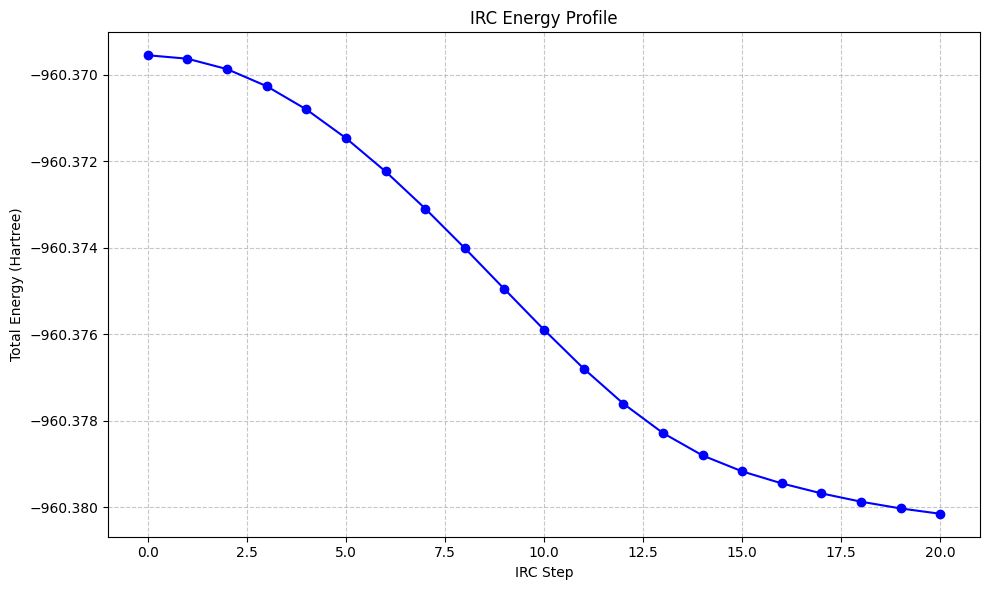

In [55]:
# データを格納するリスト
steps = []
energies = []

# ファイル読み込み
with open('ircprogress.log', 'r') as f:
    for line in f:
        # 1. @IRC で始まる行のみ対象
        if line.startswith('@IRC'):
            parts = line.split()

            # 2. 抽出条件:
            # - parts[1] が数字であること（ヘッダー行などを除外）
            # - 要素数がちょうど4つであること（Step, Energy, Change の3カラム + @IRCタグ）
            #   ※ 後半の座標データセクションは列数が多いため、これで除外できます
            if len(parts) == 4 and parts[1].isdigit():
                steps.append(int(parts[1]))
                energies.append(float(parts[2]))

# グラフ描画
if steps:
    plt.figure(figsize=(10, 6))
    plt.plot(steps, energies, marker='o', linestyle='-', color='blue')

    plt.title('IRC Energy Profile')
    plt.xlabel('IRC Step')
    plt.ylabel('Total Energy (Hartree)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Y軸の数値を省略表記(offset)にしない
    plt.ticklabel_format(useOffset=False, style='plain', axis='y')

    plt.tight_layout()
    plt.show()
else:
    print("データが見つかりませんでした。ファイル内容を確認してください。")